In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn import datasets
import time

# Part 1:

In [2]:
Data=datasets.load_iris(  as_frame=True)
print(Data.DESCR)
print(Data)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
df = pd.DataFrame(data=Data.data, columns=Data.feature_names)

df['target'] = Data.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [4]:
from sklearn . model_selection import train_test_split

X=df.values[:,0:-1]
y=df.values[:,-1]

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.3,random_state=42 )

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Scaling Explanation:
Without scaling, variables with high magnitude will affect the distance calculations, they will skew the results as if they have more weight than the rest of the variables, to ensure all variables have similar weight we must scale the data. So for example, a variable that ranges from -10000 to 10000 will not have more weight over a variable that ranges from -1 to 1 purely because of its magnitude.

# Part 2:

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [7]:
K=[0] * 30
for i,k in enumerate(K):
    knn = KNeighborsClassifier(n_neighbors=i+1)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    K[i]=(1-accuracy)

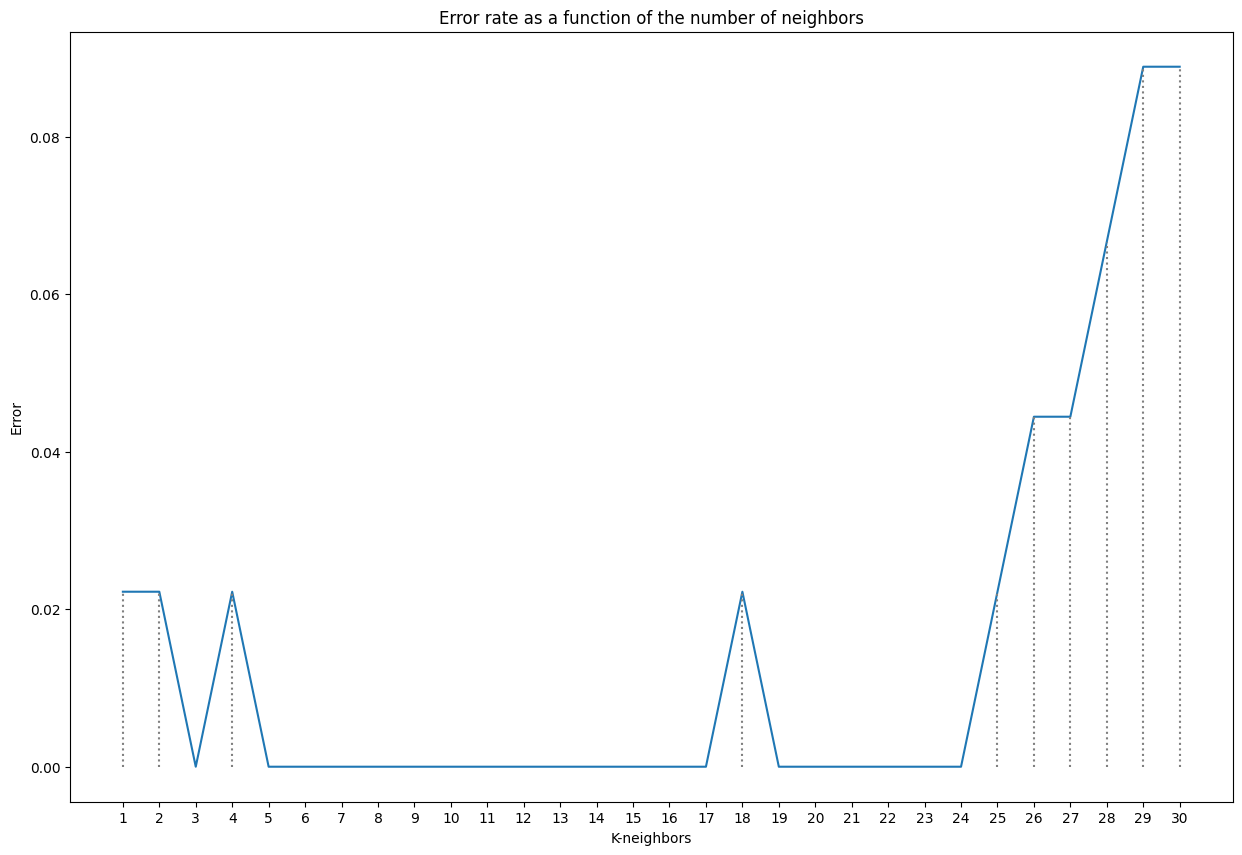

In [8]:
plt.figure(figsize =(15,10))
plt.plot(np.arange(1,31,1), K)
plt.xticks(np.arange(1,31,1))
plt.vlines(np.arange(1,31,1),0, K, linestyle="dotted", color="gray")
plt.xlabel("K-neighbors")
plt.ylabel("Error")
plt.title("Error rate as a function of the number of neighbors")
plt.show()

### Optimal value of K:
Based on the error rate analysis, the optimal value of k is 3, as it achieves the lowest error rate while maintaining the lowest model complexity.

A value of k = 1 would likely lead to overfitting, as indicated by its higher error rate compared to k = 3. This suggests that the model may have been too closely tailored to the training set, reducing its ability to generalize to unseen data.

On the other hand, higher values of k, such as 24 and above ,result in poorer performance. This is largely due to the dataset size: with only 150 samples, selecting a large k means a significant portion of the data is used for classification. For example, k = 24 represents 1/6 of the entire dataset, which can introduce bias and reduce model accuracy. In contrast, k = 3 represents only 1/50 of the data, offering a better balance between locality and generalization.

Since the dataset contains three balanced classes with 50 samples each, choosing a k value close to the class size (or total dataset size) tends to increase error by oversmoothing the decision boundaries and losing meaningful local structure.

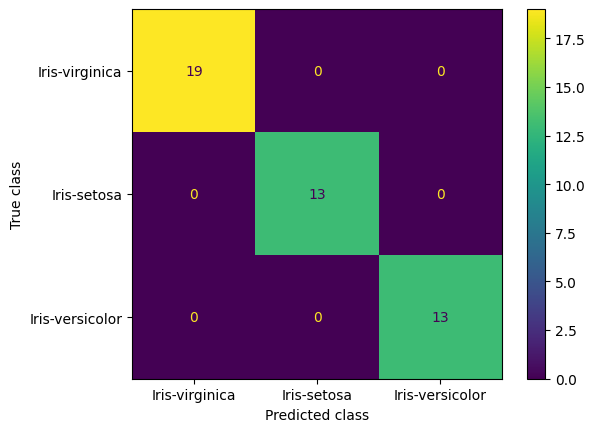

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn . metrics import ConfusionMatrixDisplay

knn = KNeighborsClassifier(n_neighbors=3)
start_time = time.time()
knn.fit(X_train_scaled, y_train)
end_time = time.time()
training_duration_knn = end_time - start_time

start_time = time.time()
y_pred=knn.predict(X_test_scaled)
end_time = time.time()
prediction_time_knn = end_time - start_time


accuracy_knn = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm ,display_labels=["Iris-virginica","Iris-setosa","Iris-versicolor"] )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt .show()

### interpretation:
the model correctly classified all the test data, this is consistent with the error rate being 0 in the previous section.

# Part 3:


In [10]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
start_time = time.time()
gnb.fit(X_train_scaled, y_train)
end_time = time.time()
training_duration_gnb = end_time - start_time

### conditional indepedance in naive bayes:
Naive Bayes assumes that all features are conditionally independent given the class. This means that within each class, knowing one feature tells us nothing about another. The assumption is necessary because it allows the model to multiply individual feature probabilities to compute the joint probability, greatly simplifying calculations. Without it, modeling dependencies would be far more complex and data-intensive.

In [11]:
from sklearn.metrics import classification_report

start_time = time.time()
y_pred=gnb.predict(X_test_scaled)
end_time = time.time()
prediction_time_gnb = end_time - start_time

accuracy_gnb = accuracy_score(y_test, y_pred)
error=(1-accuracy_gnb)
print(f"Accuracy: {accuracy_gnb:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        19
         1.0       1.00      0.92      0.96        13
         2.0       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



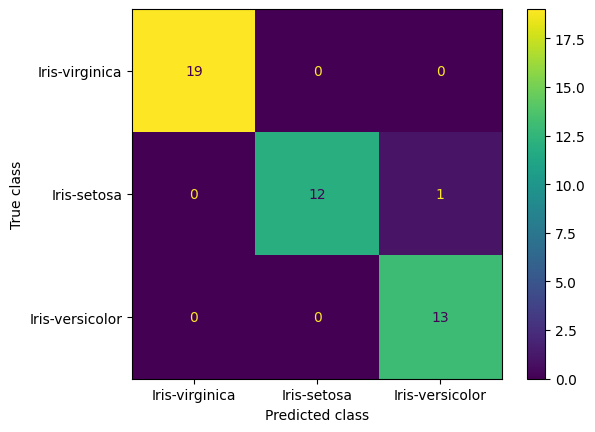

In [12]:
cm = confusion_matrix(y_test, y_pred)

display=ConfusionMatrixDisplay ( confusion_matrix=cm ,display_labels=["Iris-virginica","Iris-setosa","Iris-versicolor"] )
display.plot()
plt .xlabel("Predicted class")
plt .ylabel("True class")
plt .show()

# Part 4:

In [13]:
print("Summary:")
print("Test set accuracy :")
print(f"KNN: {accuracy_knn:.4f}")
print(f"GNB: {accuracy_gnb:.4f}")
print("Training time :")
print(f"KNN: {training_duration_knn:.4f}")
print(f"GNB: {training_duration_gnb:.4f}")
print("Prediction time:")
print(f"KNN: {prediction_time_knn:.4f}")
print(f"GNB: {prediction_time_gnb:.4f}")

Summary:
Test set accuracy :
KNN: 1.0000
GNB: 0.9778
Training time :
KNN: 0.0025
GNB: 0.0035
Prediction time:
KNN: 0.0130
GNB: 0.0019


## Discussion:
- Accuracy: KNN achieved perfect accuracy (100%) on the test set, while GNB had slightly lower performance.

- Training Time: KNN trained about 2× faster than GNB, as it does not perform intensive computations during fitting.

-  Prediction Time: KNN took nearly 6× longer than GNB to classify the test set, due to its need to compute distances to all training points during inference.

- Learning Style: KNN is a lazy learner, it memorizes the training data and defers computation until prediction. GNB is an eager learner, it builds a probabilistic model during training.

- Scalability: GNB has lower memory usage and computational complexity during prediction, making it more scalable for larger datasets.

- Model Assumptions: KNN is non-parametric and makes minimal assumptions about data structure. GNB assumes features are conditionally independent given the class, which may not hold in practice.

## Best Choice for the Iris Dataset:

Given the small size of the Iris dataset (150 samples), the computational and memory differences between the two models are negligible. Since KNN delivered higher accuracy without significant overhead in this case, it is the preferred choice for this particular classification task.